# Прогнозирование цены недвижимости (Housing)

EDA, предобработка и сравнение моделей: Linear Regression, Decision Tree, Random Forest.

## 1. Импорт библиотек

In [9]:
print("Импорт библиотек")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

Импорт библиотек


## 2. Загрузка данных

In [10]:
print("Загрузка датасета")

df = pd.read_csv("Housing.csv")
df.head()

Загрузка датасета


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Информация о датасете

In [11]:
print("Информация о датасете")
print(df.info())
print("\nСтатистика числовых признаков:")
df.describe()

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Статистика числовых признаков:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 4. Проверка пропусков

In [12]:
print("Проверка пропусков")
print(df.isnull().sum())

Проверка пропусков
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## 5. Распределение целевой переменной (price)

Распределение цены домов


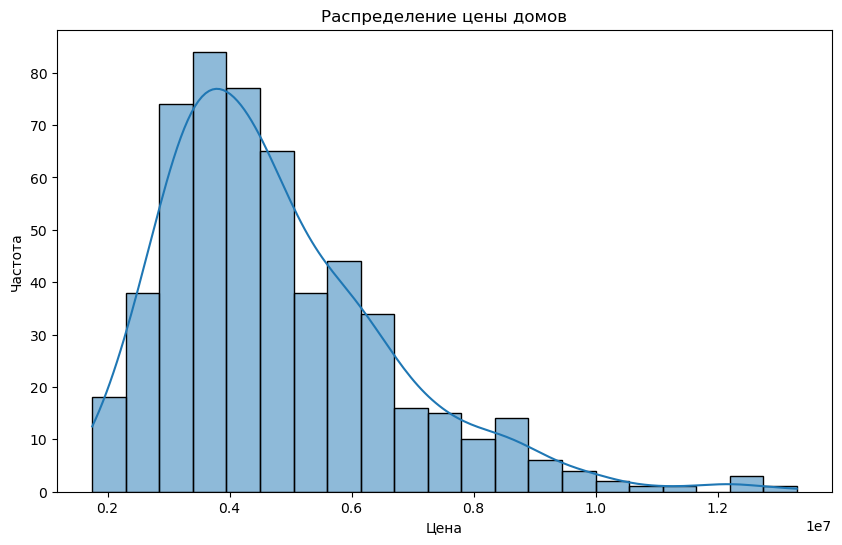

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


In [13]:
print("Распределение цены домов")

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title("Распределение цены домов")
plt.xlabel("Цена")
plt.ylabel("Частота")
plt.show()

print(df['price'].describe())

## 6. Корреляция (числовые признаки)

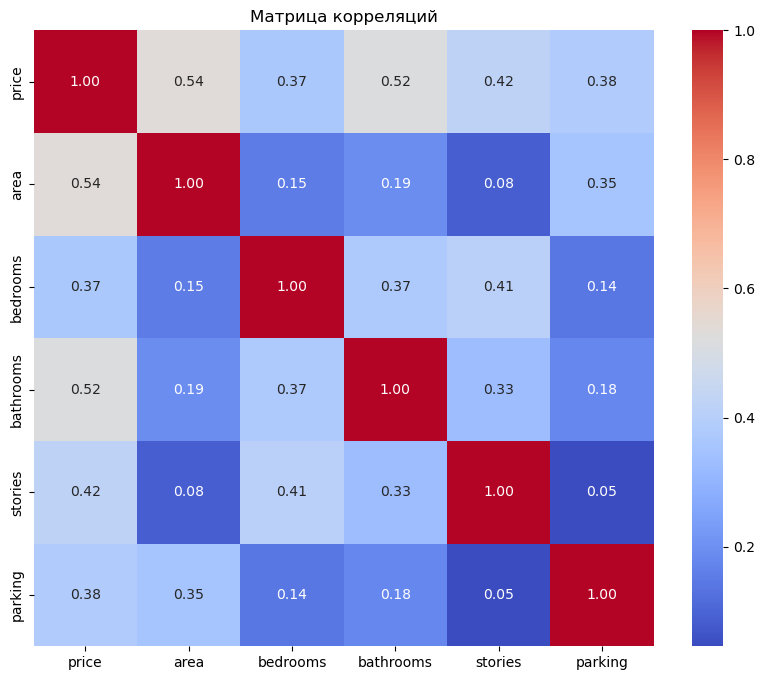

In [14]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Матрица корреляций")
plt.show()

## 7. Предобработка данных

In [15]:
print("Предобработка данных")

# Разделяем признаки
X = df.drop('price', axis=1)
y = df['price']

# Категориальные и числовые колонки
cat_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                'airconditioning', 'prefarea', 'furnishingstatus']
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Предобработка данных
Размер обучающей выборки: (436, 12)
Размер тестовой выборки: (109, 12)


## 8. Построение моделей

In [ ]:
print("Обучение моделей")

# ==================== ИМПОРТЫ ====================
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==================== МОДЕЛИ ====================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=10)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),      
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

    print(f"\n{name}:")
    print(f"MAE  = {mae:,.0f}")
    print(f"RMSE = {rmse:,.0f}")
    print(f"R²   = {r2:.4f}")

Обучение моделей

Linear Regression:
MAE  = 970,043
RMSE = 1,324,507
R²   = 0.6529

Decision Tree:
MAE  = 1,263,288
RMSE = 1,697,915
R²   = 0.4296

Random Forest:
MAE  = 1,015,869
RMSE = 1,398,418
R²   = 0.6131


## 9. Сравнение моделей

In [17]:
print("Сравнение качества моделей")
comparison = pd.DataFrame(results).T
print(comparison.round(2))

Сравнение качества моделей
                          MAE        RMSE    R²
Linear Regression   970043.40  1324506.96  0.65
Decision Tree      1263287.97  1697915.33  0.43
Random Forest      1015868.95  1398418.50  0.61


## 10. Важность признаков (Random Forest)

Важность признаков (Random Forest)
                         Признак  Важность
0                           area  0.469477
2                      bathrooms  0.154334
9            airconditioning_yes  0.061149
4                        parking  0.056472
3                        stories  0.056223
1                       bedrooms  0.046936
12  furnishingstatus_unfurnished  0.037079
7                   basement_yes  0.032316
10                  prefarea_yes  0.028315
8            hotwaterheating_yes  0.018441


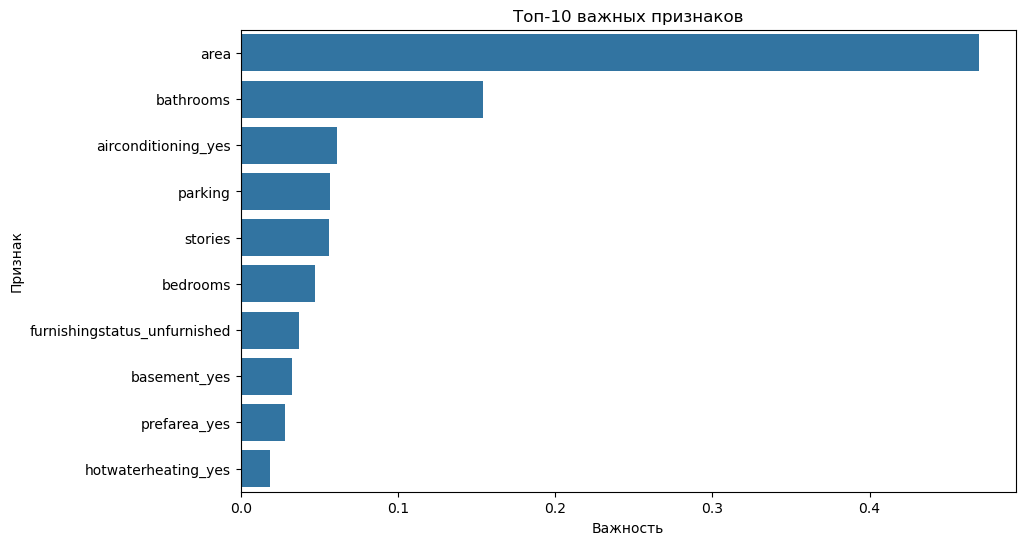

In [18]:
print("Важность признаков (Random Forest)")

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', models["Random Forest"])
])
rf_pipeline.fit(X_train, y_train)

feature_names = (num_features +
                 list(rf_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(cat_features)))

importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_imp = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values('Важность', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='Важность', y='Признак')
plt.title("Топ-10 важных признаков")
plt.show()

## 11. Бизнес-выводы

In [19]:
print("""
БИЗНЕС-ВЫВОДЫ

Наиболее значимые факторы, влияющие на цену дома:
1. Площадь (area) — главный фактор
2. Количество ванных комнат (bathrooms)
3. Наличие кондиционирования (airconditioning)
4. Расположение в престижном районе (prefarea)
5. Количество этажей (stories)

Рекомендации для бизнеса:
• При оценке недвижимости в первую очередь обращать внимание на площадь и наличие кондиционера.
• Дома в престижных районах (prefarea = yes) имеют ощутимую премию к цене.
• Наличие гостевой комнаты, подвала и парковки также положительно влияет на стоимость.
• Для риелторов полезно использовать модель для быстрой предварительной оценки объектов.
""")


БИЗНЕС-ВЫВОДЫ

Наиболее значимые факторы, влияющие на цену дома:
1. Площадь (area) — главный фактор
2. Количество ванных комнат (bathrooms)
3. Наличие кондиционирования (airconditioning)
4. Расположение в престижном районе (prefarea)
5. Количество этажей (stories)

Рекомендации для бизнеса:
• При оценке недвижимости в первую очередь обращать внимание на площадь и наличие кондиционера.
• Дома в престижных районах (prefarea = yes) имеют ощутимую премию к цене.
• Наличие гостевой комнаты, подвала и парковки также положительно влияет на стоимость.
• Для риелторов полезно использовать модель для быстрой предварительной оценки объектов.

